a)


Dataset  σ²=0.25   True Bayes error = 2.28%
   ND     Avg err    Pooled err    Bayes err
--------------------------------------------
    5       3.32%         3.32%        2.28%
       Repeats:
         rep1: μ̂1=-0.785 μ̂2=0.732 σ̂=0.292  CM=[[490,10],[15,485]]  err=2.5%
         rep2: μ̂1=-1.360 μ̂2=0.830 σ̂=0.360  CM=[[467,33],[3,497]]  err=3.6%
         rep3: μ̂1=-0.959 μ̂2=1.229 σ̂=0.458  CM=[[496,4],[33,467]]  err=3.7%
         rep4: μ̂1=-0.831 μ̂2=1.185 σ̂=0.356  CM=[[496,4],[37,463]]  err=4.1%
         rep5: μ̂1=-1.142 μ̂2=1.138 σ̂=0.591  CM=[[490,10],[17,483]]  err=2.7%
       Avg CM: [[487.8,12.2],[21.0,479.0]]  avg err=3.32%
   20       2.76%         2.76%        2.28%
       Repeats:
         rep1: μ̂1=-0.984 μ̂2=0.994 σ̂=0.409  CM=[[491,9],[18,482]]  err=2.7%
         rep2: μ̂1=-1.190 μ̂2=1.068 σ̂=0.533  CM=[[488,12],[13,487]]  err=2.5%
         rep3: μ̂1=-1.015 μ̂2=0.814 σ̂=0.504  CM=[[485,15],[10,490]]  err=2.5%
         rep4: μ̂1=-0.954 μ̂2=1.141 σ̂=0.515  CM=[[495,5]

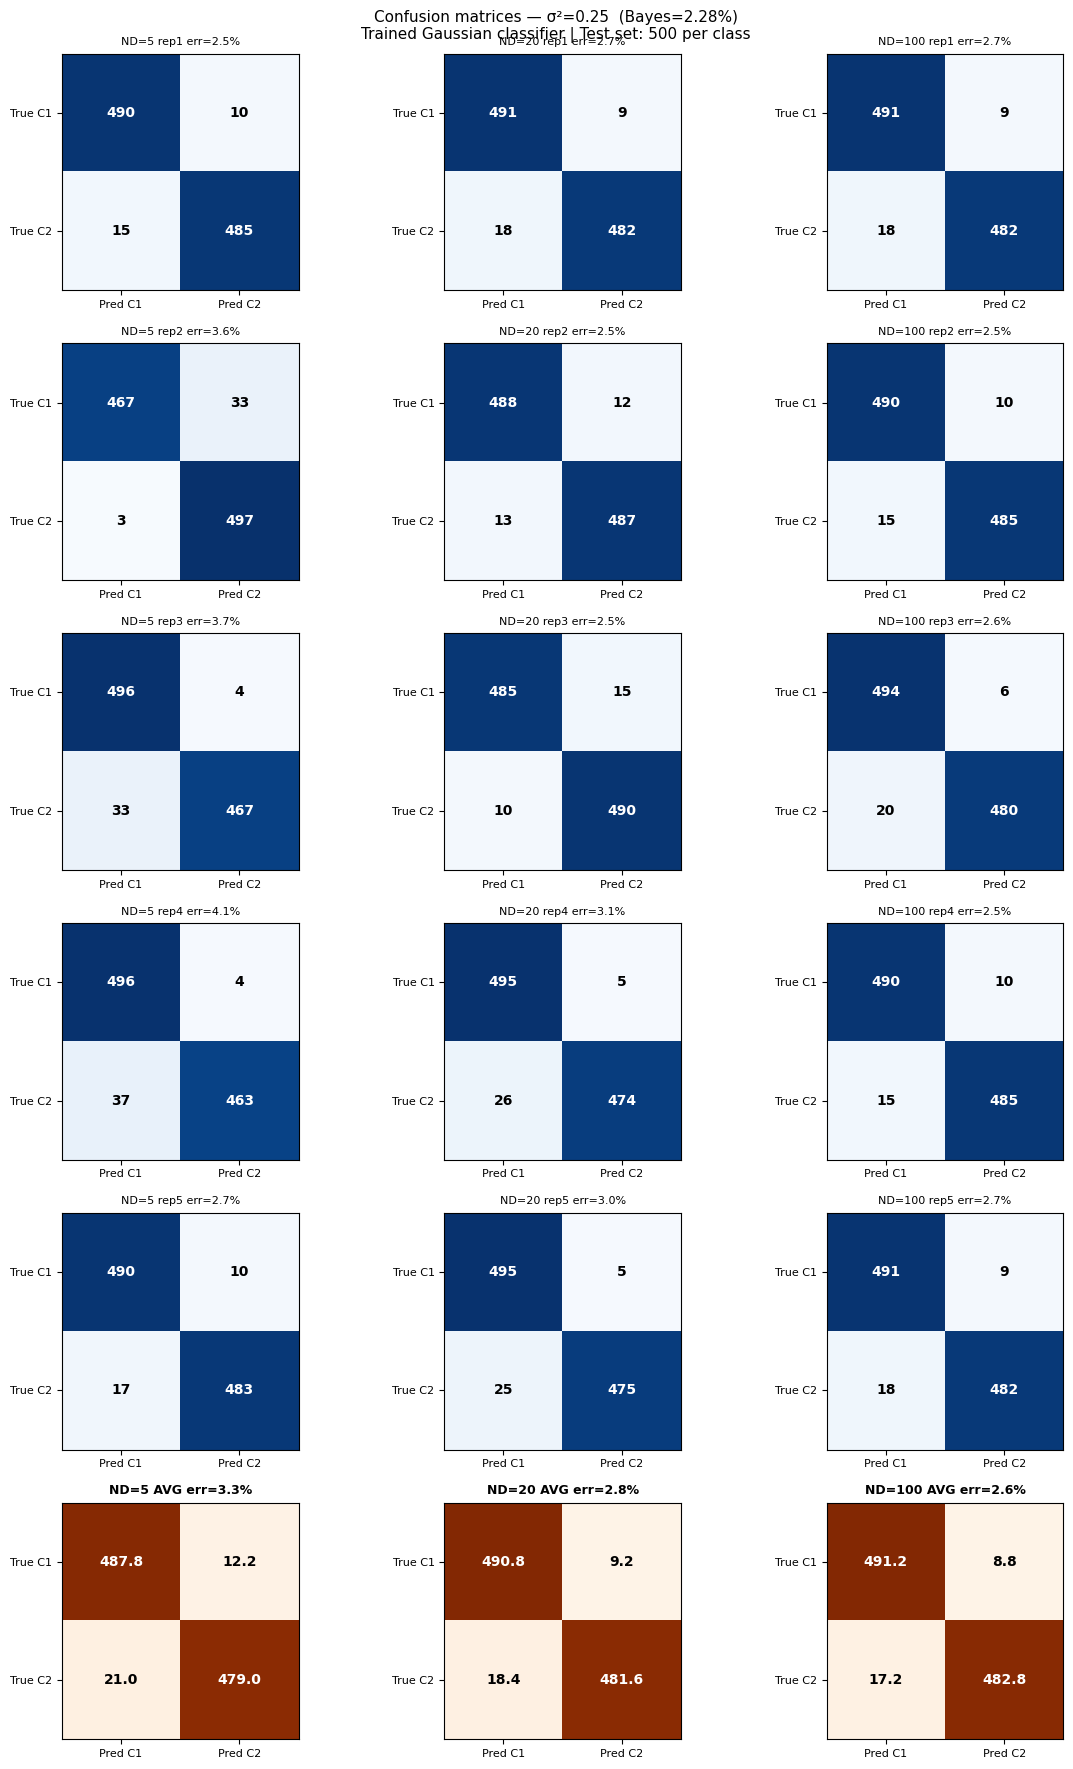

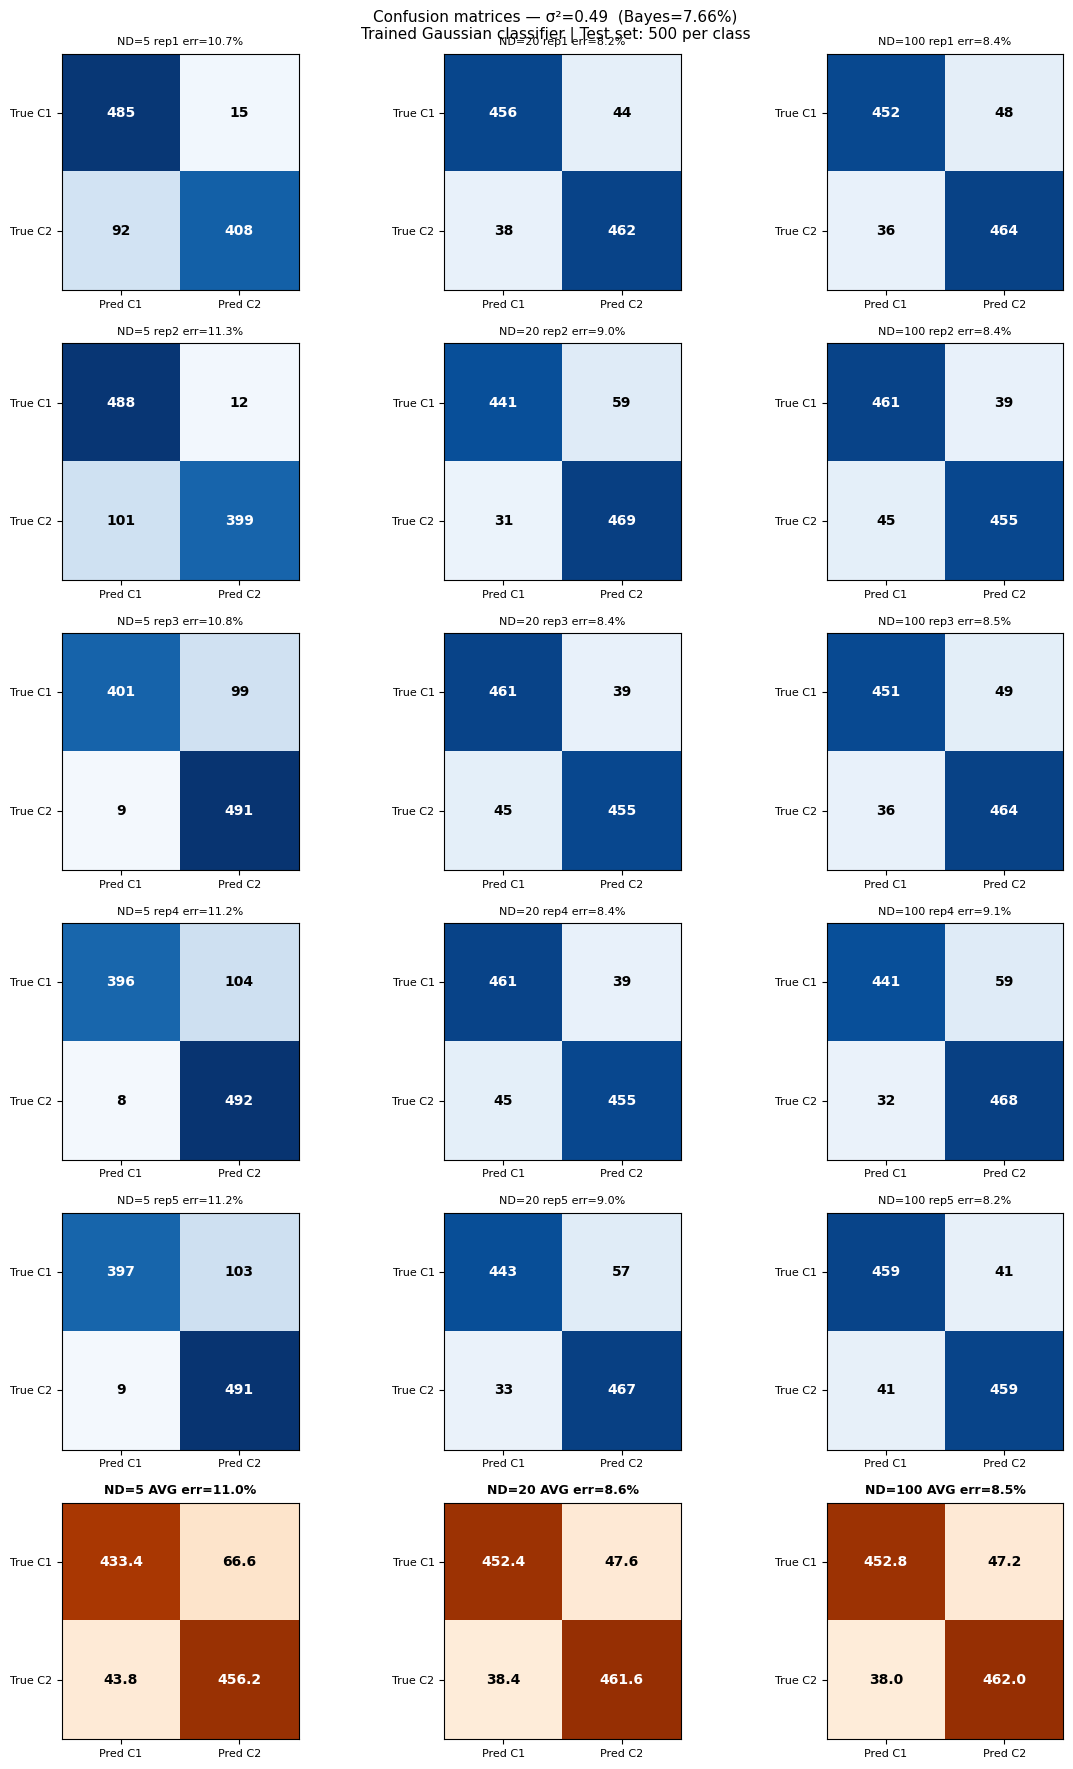

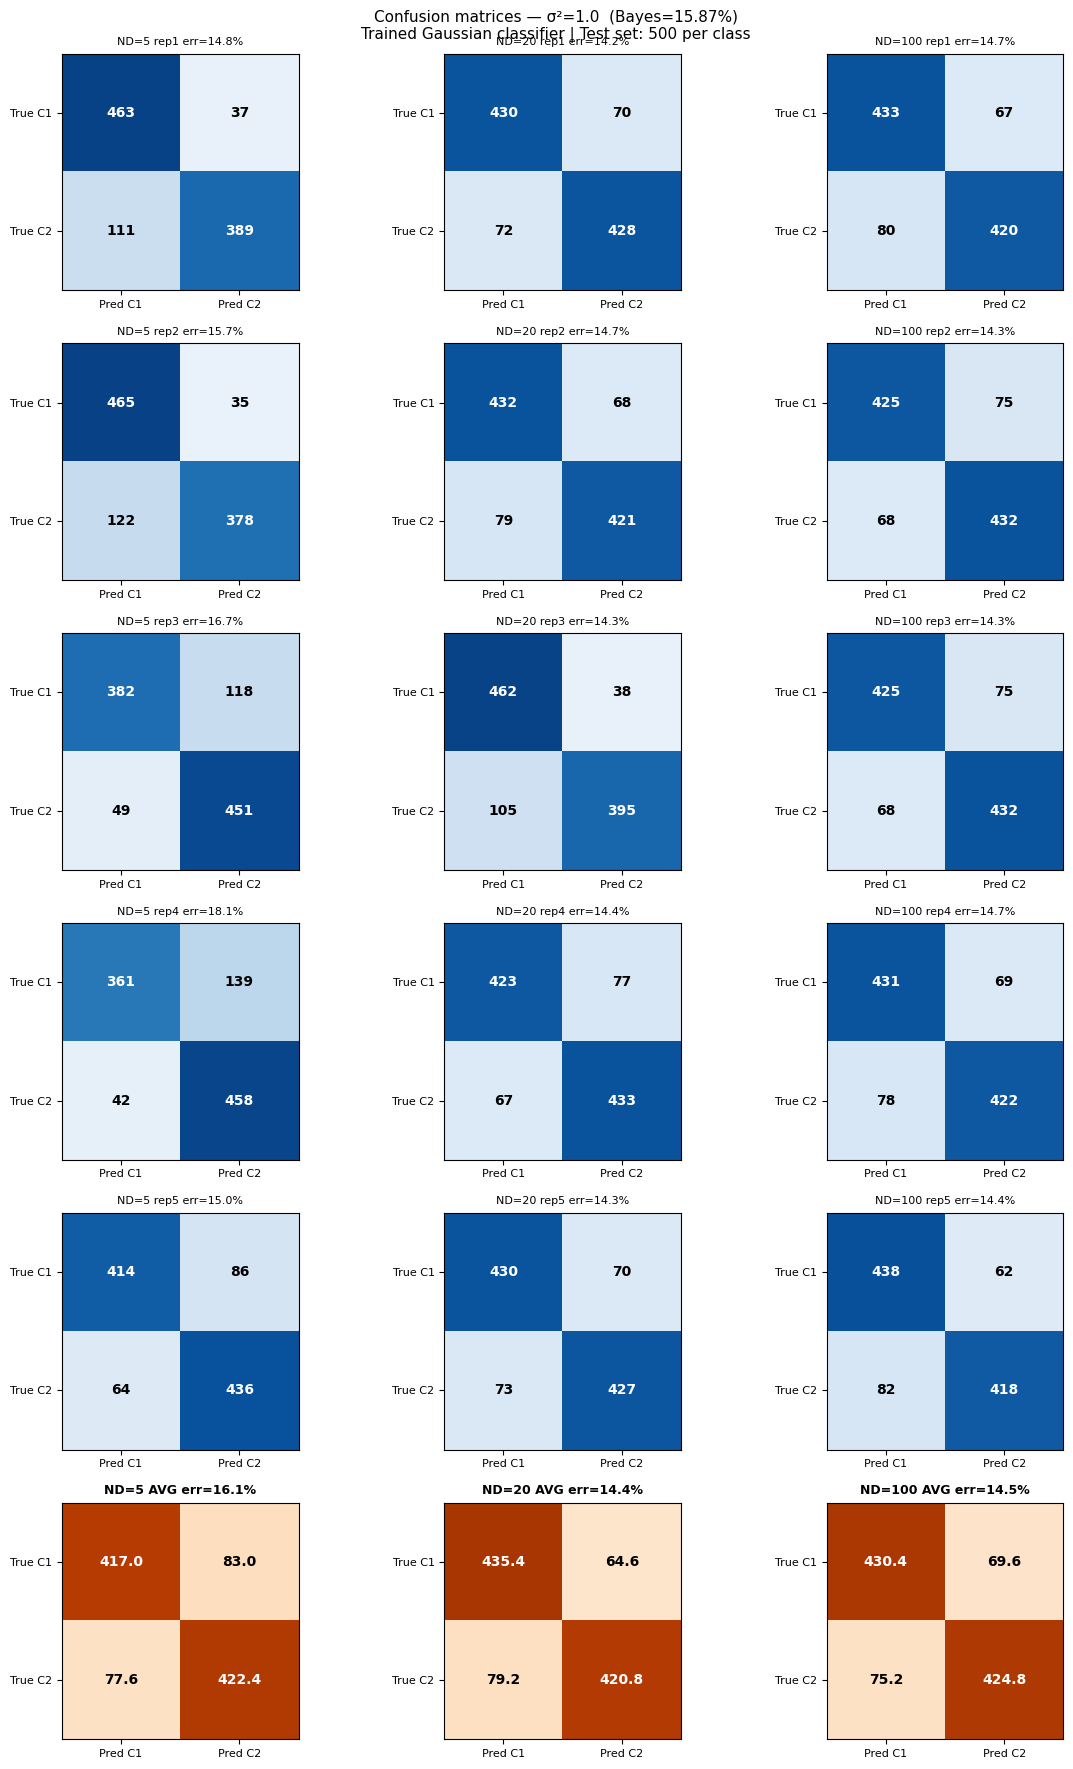

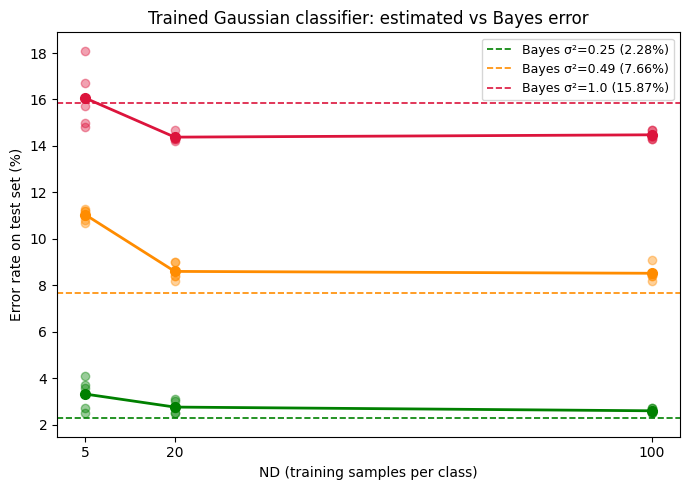

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

rng = np.random.default_rng(seed=42)

# ── Dataset definitions ───────────────────────────────────────────────────────
datasets = [
    ("datasets/dataset_1_sigma2_025.npy", 0.25),
    ("datasets/dataset_2_sigma2_049.npy", 0.49),
    ("datasets/dataset_3_sigma2_10.npy",  1.00),
]

ND_values = [5, 20, 100]   # training samples per class
N_repeats = 5
m1_true, m2_true = -1.0, 1.0

def cm2x2(y_true, y_pred):
    cm = np.zeros((2, 2), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def error_rate(cm):
    return (cm[0,1] + cm[1,0]) / cm.sum()

# ── Main experiment ───────────────────────────────────────────────────────────
# Results stored as: all_results[sigma2][ND] = (cms, errs, trained_params)
all_results = {}

for ds_path, sigma2 in datasets:
    data = np.load(ds_path)

    # Layout: rows 0-999 = class 1, rows 1000-1999 = class 2
    # Training = first 500 per class; test = last 500 per class
    train_c1 = data[:500,    0]
    train_c2 = data[1000:1500, 0]
    test_c1  = data[500:1000,  0]
    test_c2  = data[1500:2000, 0]

    # All 500 test samples used for every test
    X_test  = np.concatenate([test_c1, test_c2])
    y_test  = np.concatenate([np.zeros(500, int), np.ones(500, int)])

    # Permute training pools so slices are non-overlapping across repeats
    idx1 = rng.permutation(500)
    idx2 = rng.permutation(500)

    bayes_pe = 0.5 * erfc(abs(m2_true - m1_true) / (2 * np.sqrt(sigma2) * np.sqrt(2)))

    ds_res = {}
    print(f"\n{'='*72}")
    print(f"Dataset  σ²={sigma2}   True Bayes error = {bayes_pe*100:.2f}%")
    print(f"{'='*72}")
    print(f"{'ND':>5}  {'Avg err':>10}  {'Pooled err':>12}  {'Bayes err':>11}")
    print(f"{'-'*44}")

    for ND in ND_values:
        assert ND * N_repeats <= 500, "Not enough training samples"
        cms, errs, params = [], [], []

        for rep in range(N_repeats):
            s, e = rep * ND, (rep+1) * ND
            tr_c1 = train_c1[idx1[s:e]]
            tr_c2 = train_c2[idx2[s:e]]

            # ── MLE parameter estimation ──────────────────────────────────────
            mu1_hat  = np.mean(tr_c1)
            mu2_hat  = np.mean(tr_c2)
            # Pooled variance (equal-variance Gaussian assumption)
            var_hat   = (np.var(tr_c1, ddof=1) + np.var(tr_c2, ddof=1)) / 2
            sigma_hat = np.sqrt(var_hat)
            params.append((mu1_hat, mu2_hat, sigma_hat))

            # ── Classify test set with estimated parameters ───────────────────
            # Equal priors → assign to class with higher likelihood
            ll1 = -0.5 * ((X_test - mu1_hat) / sigma_hat) ** 2
            ll2 = -0.5 * ((X_test - mu2_hat) / sigma_hat) ** 2
            y_pred = (ll2 >= ll1).astype(int)

            cm  = cm2x2(y_test, y_pred)
            err = error_rate(cm)
            cms.append(cm); errs.append(err)

        ds_res[ND] = (cms, errs, params)

        avg_err    = np.mean(errs)
        pooled_err = sum(cm[0,1]+cm[1,0] for cm in cms) / (N_repeats * 1000)
        print(f"{ND:>5}  {avg_err*100:>9.2f}%  {pooled_err*100:>11.2f}%  {bayes_pe*100:>10.2f}%")

        print(f"       Repeats:")
        for rep, (cm, err, (mu1h, mu2h, sh)) in enumerate(zip(cms, errs, params)):
            print(f"         rep{rep+1}: μ̂1={mu1h:.3f} μ̂2={mu2h:.3f} σ̂={sh:.3f}  "
                  f"CM=[[{cm[0,0]},{cm[0,1]}],[{cm[1,0]},{cm[1,1]}]]  err={err*100:.1f}%")
        avg_cm = np.mean(cms, axis=0)
        print(f"       Avg CM: [[{avg_cm[0,0]:.1f},{avg_cm[0,1]:.1f}],"
              f"[{avg_cm[1,0]:.1f},{avg_cm[1,1]:.1f}]]  avg err={np.mean(errs)*100:.2f}%")

    all_results[sigma2] = (ds_res, bayes_pe)

# ── Confusion matrix plots ────────────────────────────────────────────────────
for ds_path, sigma2 in datasets:
    ds_res, bayes_pe = all_results[sigma2]
    fig, axes = plt.subplots(N_repeats + 1, len(ND_values),
                             figsize=(4*len(ND_values), 3*(N_repeats+1)))

    for col, ND in enumerate(ND_values):
        cms, errs, _ = ds_res[ND]
        for row in range(N_repeats):
            ax = axes[row, col]; cm = cms[row]
            ax.imshow(cm, cmap="Blues", vmin=0, vmax=500)
            ax.set_xticks([0,1]); ax.set_yticks([0,1])
            ax.set_xticklabels(["Pred C1","Pred C2"], fontsize=8)
            ax.set_yticklabels(["True C1","True C2"], fontsize=8)
            for r in range(2):
                for c in range(2):
                    ax.text(c, r, str(cm[r,c]), ha="center", va="center",
                            fontsize=10, fontweight="bold",
                            color="white" if cm[r,c] > 250 else "black")
            ax.set_title(f"ND={ND} rep{row+1} err={errs[row]*100:.1f}%", fontsize=8)

        avg_cm  = np.mean(cms, axis=0)
        avg_err = np.mean(errs)
        ax = axes[N_repeats, col]
        ax.imshow(avg_cm, cmap="Oranges", vmin=0, vmax=500)
        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xticklabels(["Pred C1","Pred C2"], fontsize=8)
        ax.set_yticklabels(["True C1","True C2"], fontsize=8)
        for r in range(2):
            for c in range(2):
                ax.text(c, r, f"{avg_cm[r,c]:.1f}", ha="center", va="center",
                        fontsize=10, fontweight="bold",
                        color="white" if avg_cm[r,c] > 250 else "black")
        ax.set_title(f"ND={ND} AVG err={avg_err*100:.1f}%", fontsize=9, fontweight="bold")

    fig.suptitle(f"Confusion matrices — σ²={sigma2}  (Bayes={bayes_pe*100:.2f}%)\n"
                 "Trained Gaussian classifier | Test set: 500 per class", fontsize=11)
    plt.tight_layout()
    plt.show()

# ── Summary: avg error vs ND for all datasets ─────────────────────────────────
fig_s, ax_s = plt.subplots(figsize=(7, 5))
colors = {0.25: "green", 0.49: "darkorange", 1.00: "crimson"}

for _, sigma2 in datasets:
    ds_res, bayes_pe = all_results[sigma2]
    col = colors[sigma2]
    avgs  = [np.mean(ds_res[ND][1])*100  for ND in ND_values]
    indiv = [[e*100 for e in ds_res[ND][1]] for ND in ND_values]
    ax_s.axhline(bayes_pe*100, color=col, linestyle="--", linewidth=1.2,
                 label=f"Bayes σ²={sigma2} ({bayes_pe*100:.2f}%)")
    for i, ND in enumerate(ND_values):
        ax_s.scatter([ND]*N_repeats, indiv[i], color=col, alpha=0.4, zorder=3)
    ax_s.plot(ND_values, avgs, "o-", color=col, linewidth=2, markersize=7)

ax_s.set_xlabel("ND (training samples per class)")
ax_s.set_ylabel("Error rate on test set (%)")
ax_s.set_title("Trained Gaussian classifier: estimated vs Bayes error")
ax_s.legend(fontsize=9)
ax_s.set_xticks(ND_values)
plt.tight_layout()
plt.show()

b)

In [2]:
import numpy as np

# ── (b) Average of 5 error rates vs. training on the pooled set ──────────────
# When all 5 training sets are pooled, we get 5*ND samples per class.
# The trained classifier may differ from the per-repeat classifiers
# because the estimated parameters change with more data.
#
# Comparison:
#   Method A: average of 5 error rates (each trained on ND samples)
#   Method B: train ONCE on the full 5*ND pool, test on all 500 per class

rng_b = np.random.default_rng(seed=99)

print("Part (b): Avg of 5 rates  vs.  single model trained on pooled 5×ND samples")
print("=" * 74)

for ds_path, sigma2 in datasets:
    data     = np.load(ds_path)
    train_c1 = data[:500,      0]
    train_c2 = data[1000:1500, 0]
    X_test   = np.concatenate([data[500:1000, 0], data[1500:2000, 0]])
    y_test   = np.concatenate([np.zeros(500, int), np.ones(500, int)])

    idx1 = rng_b.permutation(500)
    idx2 = rng_b.permutation(500)

    print(f"\n  σ² = {sigma2}")
    print(f"  {'ND':>5}  {'Avg(5 rates)':>14}  {'Pooled-train err':>17}  {'Same?':>7}")
    print(f"  {'-'*50}")

    for ND in ND_values:
        # Method A: re-run 5 repeats, average error rates
        errs_a = []
        pool_tr_c1, pool_tr_c2 = [], []
        for rep in range(N_repeats):
            s, e = rep*ND, (rep+1)*ND
            tr_c1 = train_c1[idx1[s:e]]
            tr_c2 = train_c2[idx2[s:e]]
            pool_tr_c1.append(tr_c1)
            pool_tr_c2.append(tr_c2)

            mu1h = np.mean(tr_c1); mu2h = np.mean(tr_c2)
            sh   = np.sqrt((np.var(tr_c1, ddof=1) + np.var(tr_c2, ddof=1)) / 2)
            ll1  = -0.5 * ((X_test - mu1h) / sh) ** 2
            ll2  = -0.5 * ((X_test - mu2h) / sh) ** 2
            y_pred = (ll2 >= ll1).astype(int)
            errs_a.append(np.mean(y_pred != y_test))

        avg_a = np.mean(errs_a)

        # Method B: train on the pooled 5*ND samples from same slices
        pool_c1 = np.concatenate(pool_tr_c1)
        pool_c2 = np.concatenate(pool_tr_c2)
        mu1h_p  = np.mean(pool_c1); mu2h_p = np.mean(pool_c2)
        sh_p    = np.sqrt((np.var(pool_c1, ddof=1) + np.var(pool_c2, ddof=1)) / 2)
        ll1_p   = -0.5 * ((X_test - mu1h_p) / sh_p) ** 2
        ll2_p   = -0.5 * ((X_test - mu2h_p) / sh_p) ** 2
        err_b   = np.mean((ll2_p >= ll1_p).astype(int) != y_test)

        same = np.isclose(avg_a, err_b, atol=1e-4)
        print(f"  {ND:>5}  {avg_a*100:>13.3f}%  {err_b*100:>16.3f}%  {'YES' if same else 'NO':>7}")

print()
print("Conclusion:")
print("  The two values generally DIFFER. Unlike the test-set averaging in Task 1,")
print("  here each repeat trains a DIFFERENT model (on ND samples) and evaluates")
print("  on the same 500 test samples. The average of those 5 error rates reflects")
print("  the expected error of a model trained on ND samples.")
print()
print("  Pooling the training data trains a SINGLE, BETTER model on 5×ND samples.")
print("  This model has lower variance in its parameter estimates (closer to the")
print("  true μ1, μ2, σ), so it typically achieves a LOWER error rate than the")
print("  average of the 5 individually-trained models — especially for small ND.")
print()
print("  The gap shrinks as ND grows, because with ND=100 each individual model")
print("  already estimates the parameters well.")

Part (b): Avg of 5 rates  vs.  single model trained on pooled 5×ND samples

  σ² = 0.25
     ND    Avg(5 rates)   Pooled-train err    Same?
  --------------------------------------------------
      5          3.120%             2.400%       NO
     20          2.800%             2.500%       NO
    100          2.580%             2.600%       NO

  σ² = 0.49
     ND    Avg(5 rates)   Pooled-train err    Same?
  --------------------------------------------------
      5          9.220%             9.100%       NO
     20          9.060%             9.000%       NO
    100          8.660%             8.200%       NO

  σ² = 1.0
     ND    Avg(5 rates)   Pooled-train err    Same?
  --------------------------------------------------
      5         15.920%            14.400%       NO
     20         14.800%            14.500%       NO
    100         14.480%            14.600%       NO

Conclusion:
  The two values generally DIFFER. Unlike the test-set averaging in Task 1,
  here each rep